# Taller 3.1: Regresión con datos de calidad del aire (PM2.5)
**Palacios Yoichi, Proyecto Integrador (C7328)**

Datos: EPA AQS, concentración diaria de PM2.5 (parámetro 88101), una estación (Davenport, Iowa, 2023).
Objetivo: predecir `Daily AQI Value` con regresión lineal múltiple y con un árbol de decisión, y comparar con MSE, MAE y R².

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn import metrics

%matplotlib inline
sns.set_theme(style="whitegrid")
# Carpeta de figuras (raíz del repo / Recursos / Imágenes)
IMG = os.path.abspath(os.path.join("..", "..", "..", "..", "..", "Recursos", "Imágenes"))
os.makedirs(IMG, exist_ok=True)
def guardar(nombre):
    plt.savefig(os.path.join(IMG, f"Taller31_Palacios_{nombre}.png"), dpi=130, bbox_inches="tight")
print(IMG)

C:\Users\Usuario\Documents\Portfolio\laptop\PI_wt_talleres\Recursos\Imágenes


## 1. Carga y exploración (EDA)

In [2]:
df = pd.read_csv("ad_viz_plotval_data_PM25_2023.csv")
df.head()

,Date,Source,Site ID,POC,Daily Mean PM2.5 Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,...,AQS Parameter Description,Method Code,CBSA Code,CBSA Name,State FIPS Code,State,County FIPS Code,County,Site Latitude,Site Longitude
0,01/01/2023,AQS,191630015,3,18.4,ug/m3 LC,68,"DAVENPORT, JEFFERSON SCH.",1,100.0,...,PM2.5 - Local Conditions,236,NaN,"Davenport-Moline-Rock Island, IA-IL",19,Iowa,163,Scott,41.530011,-90.587611
1,01/02/2023,AQS,191630015,3,16.4,ug/m3 LC,65,"DAVENPORT, JEFFERSON SCH.",1,100.0,...,PM2.5 - Local Conditions,236,NaN,"Davenport-Moline-Rock Island, IA-IL",19,Iowa,163,Scott,41.530011,-90.587611
2,01/03/2023,AQS,191630015,3,5.7,ug/m3 LC,32,"DAVENPORT, JEFFERSON SCH.",1,100.0,...,PM2.5 - Local Conditions,236,NaN,"Davenport-Moline-Rock Island, IA-IL",19,Iowa,163,Scott,41.530011,-90.587611
3,01/04/2023,AQS,191630015,3,12.4,ug/m3 LC,57,"DAVENPORT, JEFFERSON SCH.",1,100.0,...,PM2.5 - Local Conditions,236,NaN,"Davenport-Moline-Rock Island, IA-IL",19,Iowa,163,Scott,41.530011,-90.587611
4,01/05/2023,AQS,191630015,3,9.5,ug/m3 LC,52,"DAVENPORT, JEFFERSON SCH.",1,100.0,...,PM2.5 - Local Conditions,236,NaN,"Davenport-Moline-Rock Island, IA-IL",19,Iowa,163,Scott,41.530011,-90.587611


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 21 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Date                            360 non-null    str    
 1   Source                          360 non-null    str    
 2   Site ID                         360 non-null    int64  
 3   POC                             360 non-null    int64  
 4   Daily Mean PM2.5 Concentration  360 non-null    float64
 5   Units                           360 non-null    str    
 6   Daily AQI Value                 360 non-null    int64  
 7   Local Site Name                 360 non-null    str    
 8   Daily Obs Count                 360 non-null    int64  
 9   Percent Complete                360 non-null    float64
 10  AQS Parameter Code              360 non-null    int64  
 11  AQS Parameter Description       360 non-null    str    
 12  Method Code                     360 non-null   

In [4]:
print("Nulos por columna (solo las que tienen):")
print(df.isna().sum()[df.isna().sum() > 0])
print("Filas:", len(df), "| Fechas únicas:", df["Date"].nunique())
print("Columnas constantes:", [c for c in df.columns if df[c].nunique() == 1])

Nulos por columna (solo las que tienen):
CBSA Code    360
dtype: int64
Filas: 360 | Fechas únicas: 360
Columnas constantes: ['Source', 'Site ID', 'POC', 'Units', 'Local Site Name', 'Daily Obs Count', 'Percent Complete', 'AQS Parameter Code', 'AQS Parameter Description', 'Method Code', 'CBSA Name', 'State FIPS Code', 'State', 'County FIPS Code', 'County', 'Site Latitude', 'Site Longitude']


In [5]:
df["Date"] = pd.to_datetime(df["Date"], format="%m/%d/%Y")
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["DayOfWeek"] = df["Date"].dt.dayofweek
df = df.rename(columns={"Daily Mean PM2.5 Concentration": "PM25", "Daily AQI Value": "AQI"})
df[["PM25", "AQI", "Month", "Day", "DayOfWeek"]].describe().round(2)

,PM25,AQI,Month,Day,DayOfWeek
count,360.00,360.00,360.00,360.00,360.00
mean,11.40,50.25,6.50,15.55,2.98
std,11.02,20.88,3.43,8.75,2.01
min,2.20,12.00,1.00,1.00,0.00
25%,6.80,38.00,4.00,8.00,1.00
50%,9.50,52.00,7.00,15.50,3.00
75%,12.70,58.00,9.00,23.00,5.00
max,144.00,219.00,12.00,31.00,6.00


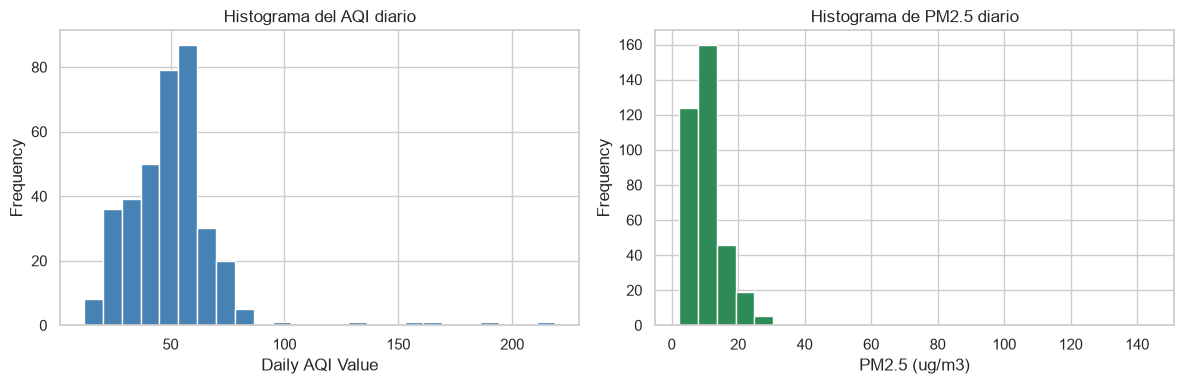

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df["AQI"].plot.hist(bins=25, ax=ax[0], color="steelblue")
ax[0].set_title("Histograma del AQI diario"); ax[0].set_xlabel("Daily AQI Value")
df["PM25"].plot.hist(bins=25, ax=ax[1], color="seagreen")
ax[1].set_title("Histograma de PM2.5 diario"); ax[1].set_xlabel("PM2.5 (ug/m3)")
plt.tight_layout(); guardar("01_histogramas"); plt.show()

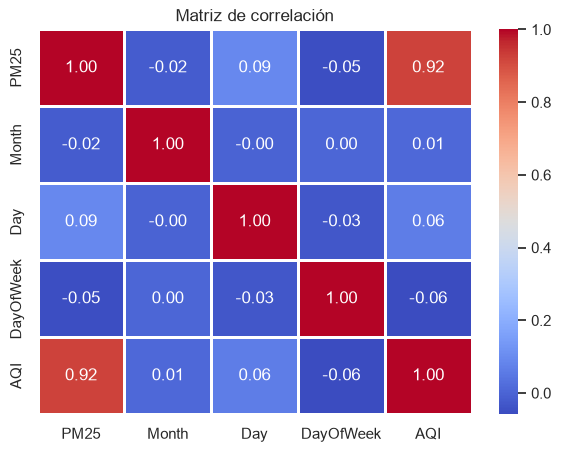

PM25         0.923
Month        0.008
Day          0.062
DayOfWeek   -0.059
AQI          1.000
Name: AQI, dtype: float64


In [7]:
num = df[["PM25", "Month", "Day", "DayOfWeek", "AQI"]]
plt.figure(figsize=(7, 5))
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="coolwarm", linewidths=2)
plt.title("Matriz de correlación")
guardar("02_heatmap"); plt.show()
print(num.corr()["AQI"].round(3))

## 2. ¿De dónde sale el AQI?
La EPA calcula el AQI con una función **por tramos** a partir de la concentración. Aquí verifico qué tabla de cortes usa el archivo: la anterior (12.0 µg/m³ como límite del nivel "Bueno") o la revisada en 2024 (9.0 µg/m³).

In [8]:
old = [(0.0, 12.0, 0, 50), (12.1, 35.4, 51, 100), (35.5, 55.4, 101, 150), (55.5, 150.4, 151, 200),
       (150.5, 250.4, 201, 300), (250.5, 350.4, 301, 400), (350.5, 500.4, 401, 500)]
new = [(0.0, 9.0, 0, 50), (9.1, 35.4, 51, 100), (35.5, 55.4, 101, 150), (55.5, 125.4, 151, 200),
       (125.5, 225.4, 201, 300), (225.5, 325.4, 301, 500)]
def aqi(c, tabla):
    c = np.floor(c * 10) / 10          # la EPA trunca a 1 decimal
    for lo, hi, ilo, ihi in tabla:
        if lo <= c <= hi:
            return round((ihi - ilo) / (hi - lo) * (c - lo) + ilo)
    return np.nan
df["AQI_old"] = df["PM25"].apply(lambda c: aqi(c, old))
df["AQI_new"] = df["PM25"].apply(lambda c: aqi(c, new))
for n in ["AQI_old", "AQI_new"]:
    ok = (df[n] == df["AQI"]).mean()
    print(f"{n}: coincide con el AQI del archivo en {ok:.1%} de los días (error absoluto máx. {(df[n]-df['AQI']).abs().max()})")

AQI_old: coincide con el AQI del archivo en 0.6% de los días (error absoluto máx. 22)
AQI_new: coincide con el AQI del archivo en 100.0% de los días (error absoluto máx. 0)


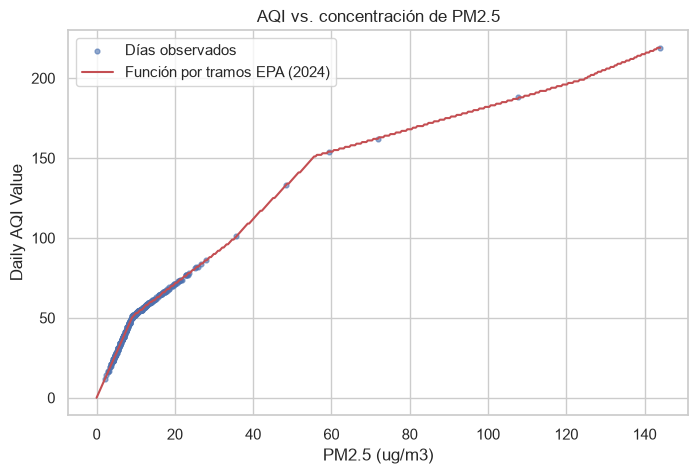

In [9]:
x = np.linspace(0, df["PM25"].max(), 400)
plt.figure(figsize=(8, 5))
plt.scatter(df["PM25"], df["AQI"], s=12, alpha=0.6, label="Días observados")
plt.plot(x, [aqi(c, new) for c in x], "r-", lw=1.5, label="Función por tramos EPA (2024)")
plt.xlabel("PM2.5 (ug/m3)"); plt.ylabel("Daily AQI Value"); plt.legend()
plt.title("AQI vs. concentración de PM2.5")
guardar("03_pm25_vs_aqi"); plt.show()

## 3. Regresión lineal múltiple (objetivo: `AQI`, `random_state=123`)

In [10]:
feat = ["PM25", "Month", "Day", "DayOfWeek"]
X = df[feat]; Y = df["AQI"]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=123)
print(X_train.shape, X_test.shape)
lm = LinearRegression().fit(X_train, Y_train)
print("Intercepto:", lm.intercept_)
coef = pd.DataFrame(lm.coef_, index=feat, columns=["Coeficiente"])
coef

(252, 4) (108, 4)
Intercepto: 30.51783748165507


,Coeficiente
PM25,1.729129
Month,0.153019
Day,-0.045043
DayOfWeek,-0.120730


In [11]:
def evaluar(nombre, modelo, Xa, Xb):
    out = {}
    for lab, Xs, Ys in [("train", Xa, Y_train), ("test", Xb, Y_test)]:
        p = modelo.predict(Xs)
        out[lab] = (metrics.mean_squared_error(Ys, p), metrics.mean_absolute_error(Ys, p), metrics.r2_score(Ys, p))
    return {"Modelo": nombre, "MSE test": out["test"][0], "MAE test": out["test"][1], "R2 test": out["test"][2],
            "R2 train": out["train"][2]}
res = [evaluar("Lineal múltiple (PM25 + fecha)", lm, X_train, X_test)]
pred_lm = lm.predict(X_test)

## 4. Árbol de decisión

In [12]:
dt = DecisionTreeRegressor(random_state=123).fit(X_train, Y_train)
res.append(evaluar("Árbol (sin límite de profundidad)", dt, X_train, X_test))
dt4 = DecisionTreeRegressor(max_depth=4, random_state=123).fit(X_train, Y_train)
res.append(evaluar("Árbol (max_depth=4)", dt4, X_train, X_test))
print("Profundidad del árbol completo:", dt.get_depth(), "| hojas:", dt.get_n_leaves())
pd.Series(dt.feature_importances_, index=feat).round(4)

Profundidad del árbol completo: 8 | hojas: 65


PM25         0.9958
Month        0.0000
Day          0.0042
DayOfWeek    0.0000
dtype: float64

## 5. Variante sin la concentración
Si quito `PM25` y dejo solo variables de calendario, el modelo ya no puede reconstruir la fórmula. Sirve para ver cuánto del R² viene de la identidad.

In [13]:
feat_t = ["Month", "Day", "DayOfWeek"]
Xt_train, Xt_test = X_train[feat_t], X_test[feat_t]
lm_t = LinearRegression().fit(Xt_train, Y_train)
dt_t = DecisionTreeRegressor(max_depth=4, random_state=123).fit(Xt_train, Y_train)
res.append(evaluar("Lineal solo calendario", lm_t, Xt_train, Xt_test))
res.append(evaluar("Árbol max_depth=4 solo calendario", dt_t, Xt_train, Xt_test))
# Modelo nulo: predecir siempre la media del entrenamiento
nulo = np.full(len(Y_test), Y_train.mean())
print("Modelo nulo (media):  MSE=%.2f  MAE=%.2f  R2=%.3f" % (metrics.mean_squared_error(Y_test, nulo),
      metrics.mean_absolute_error(Y_test, nulo), metrics.r2_score(Y_test, nulo)))

Modelo nulo (media):  MSE=484.25  MAE=13.86  R2=-0.006


## 6. Comparación de métricas

In [14]:
tabla = pd.DataFrame(res).set_index("Modelo").round(3)
tabla

,MSE test,MAE test,R2 test,R2 train
Modelo,,,,
Lineal múltiple (PM25 + fecha),54.570,6.016,0.887,0.835
Árbol (sin límite de profundidad),10.657,0.620,0.978,1.000
Árbol (max_depth=4),16.396,2.458,0.966,0.981
Lineal solo calendario,481.669,14.125,-0.000,0.008
Árbol max_depth=4 solo calendario,454.214,13.232,0.057,0.592


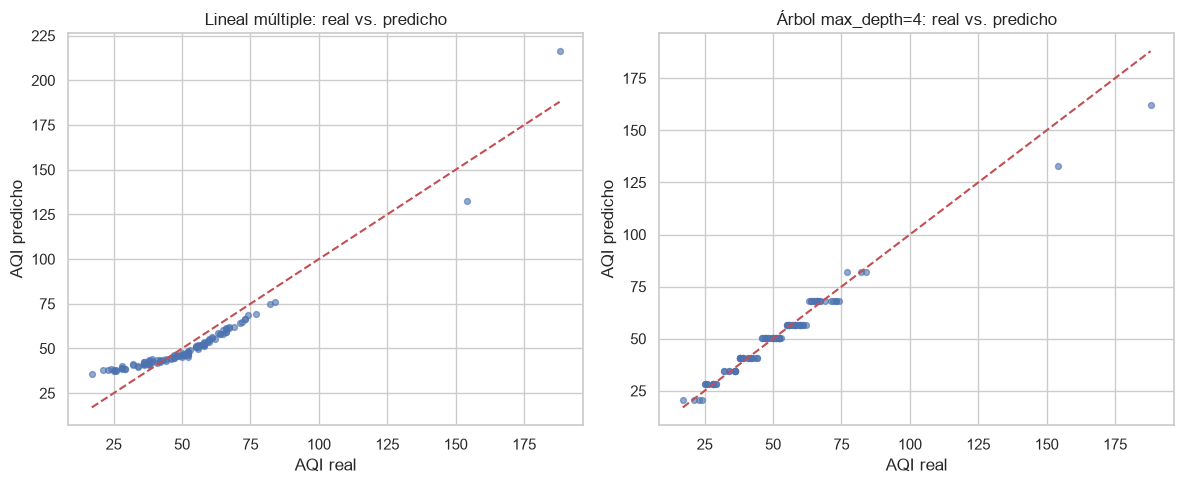

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
for a, p, t in [(ax[0], pred_lm, "Lineal múltiple"), (ax[1], dt4.predict(X_test), "Árbol max_depth=4")]:
    a.scatter(Y_test, p, alpha=0.6, s=18)
    a.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], "r--")
    a.set_title(f"{t}: real vs. predicho"); a.set_xlabel("AQI real"); a.set_ylabel("AQI predicho")
plt.tight_layout(); guardar("04_real_vs_predicho"); plt.show()

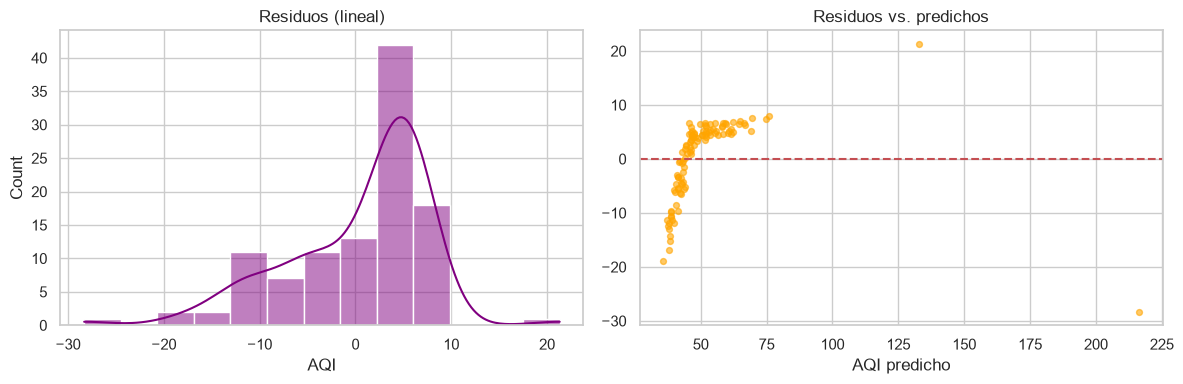

Residuo máximo absoluto: 28.33 | desviación: 7.41


In [16]:
res_l = Y_test - pred_lm
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(res_l, kde=True, ax=ax[0], color="purple"); ax[0].set_title("Residuos (lineal)")
ax[1].scatter(pred_lm, res_l, alpha=0.6, s=18, color="orange"); ax[1].axhline(0, color="r", ls="--")
ax[1].set_title("Residuos vs. predichos"); ax[1].set_xlabel("AQI predicho")
plt.tight_layout(); guardar("05_residuos"); plt.show()
print("Residuo máximo absoluto:", res_l.abs().max().round(2), "| desviación:", res_l.std().round(2))

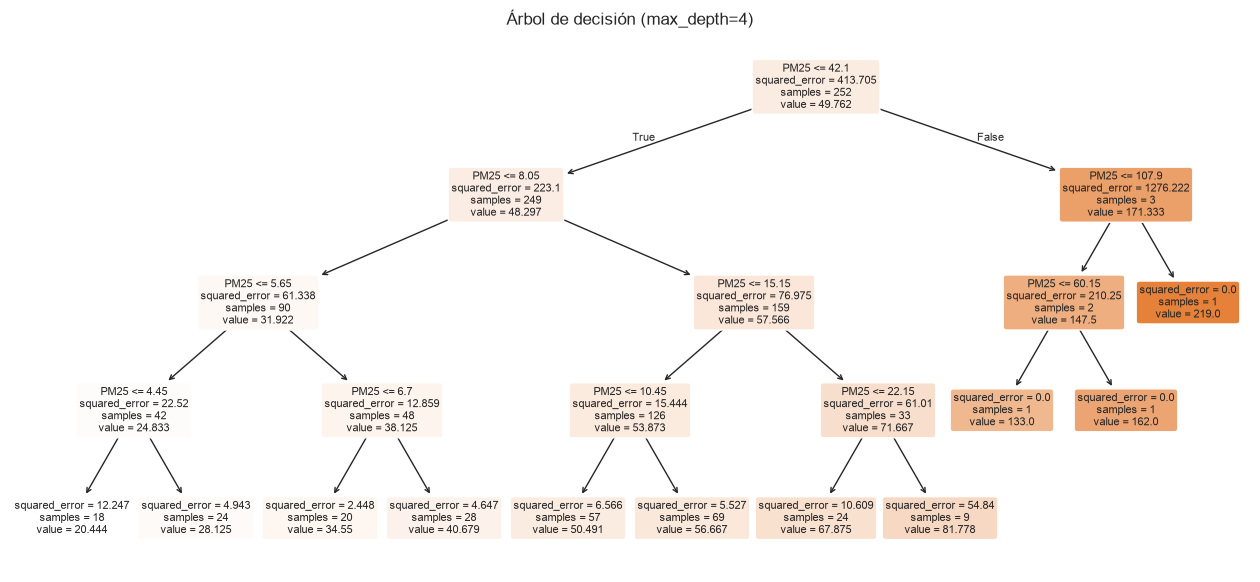

In [17]:
plt.figure(figsize=(16, 7))
plot_tree(dt4, feature_names=feat, filled=True, rounded=True, fontsize=8)
plt.title("Árbol de decisión (max_depth=4)")
guardar("06_arbol"); plt.show()

## 7. Interpretación de coeficientes

In [18]:
print("Coeficientes (lineal con PM25 + calendario):")
print(coef.round(4))
# Pendiente local de la función por tramos: AQI sube 49/26.3 por ug/m3 en el tramo 9.1-35.4
print("Pendiente teórica del tramo 9.1-35.4 ug/m3:", round(49/26.3, 3))
print("Pendiente teórica del tramo 55.5-125.4 ug/m3:", round(49/69.9, 3))
print("Coeficientes (lineal solo calendario):")
print(pd.Series(lm_t.coef_, index=feat_t).round(4))

Coeficientes (lineal con PM25 + calendario):
           Coeficiente
PM25            1.7291
Month           0.1530
Day            -0.0450
DayOfWeek      -0.1207
Pendiente teórica del tramo 9.1-35.4 ug/m3: 1.863
Pendiente teórica del tramo 55.5-125.4 ug/m3: 0.701
Coeficientes (lineal solo calendario):
Month       -0.0269
Day          0.1520
DayOfWeek   -0.5384
dtype: float64
